# ALL-IDB1 Hybrid CNN + Transformer

VGG11-BN spatial features plus a positional Transformer encoder, trained from random initialization only. Evaluation is grouped by acquisition bursts inferred from label-blind EXIF camera/time metadata to reduce camera, slide-session, and near-sequence leakage.

## Objective and success criteria

- Validate the real 59 healthy / 49 leukemia ALL-IDB1 files.
- Prove that both the CNN and Transformer start with `weights=None`.
- Expose camera, resolution, duplicate, and acquisition-burst confounding.
- White-balance each image, preserve aspect ratio, and build a label-blind global/leukocyte mosaic.
- Use five-fold acquisition-grouped out-of-fold evaluation over all 108 source files.
- Bootstrap confidence intervals by acquisition group rather than individual image.
- Save fold histories, gaps, predictions, metrics, plots, embeddings, and checkpoints.


## 1. Reproducible setup

In [1]:
from __future__ import annotations

import json
import os
from pathlib import Path
import random
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image as PILImage
from IPython.display import Image, display
import torch
import torch.nn as nn
import torch.optim as optim

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT))

import importlib
import leukemia_osl.data as data_module
import leukemia_osl.model as model_module
import leukemia_osl.preprocess as preprocess_module
import leukemia_osl.results as results_module
import train as train_module

for module in (model_module, preprocess_module, data_module, results_module, train_module):
    importlib.reload(module)

from leukemia_osl.model import create_model
from leukemia_osl.preprocess import (
    acquisition_group_ids,
    build_manifest,
    find_duplicate_content,
    summarize_records,
    validate_prepared_all_idb1,
)
from leukemia_osl.results import compute_result_metrics, save_result_bundle
from train import evaluate, set_seed, train_one_epoch

SEED = 42
set_seed(SEED)
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("Project:", PROJECT_ROOT)
print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

Project: /Users/panshulaj/Documents/AIML proj
Python: /Users/panshulaj/Documents/AIML proj/.venv/bin/python
PyTorch: 2.13.0
Device: mps


## 2. Prepare and validate real ALL-IDB1

This notebook uses the extracted dataset folder supplied for this project: `/Users/panshulaj/Downloads/ALL_IDB1`. The cell below rebuilds the processed ImageFolder split from that folder and stops if the real 108-image dataset is unavailable.

In [2]:
SOURCE_DIR = Path("/Users/panshulaj/Downloads/ALL_IDB1")
DATA_DIR = PROJECT_ROOT / "data" / "processed" / "all_idb1"

if not SOURCE_DIR.is_dir():
    raise FileNotFoundError(f"Expected extracted ALL-IDB1 dataset folder: {SOURCE_DIR}")

subprocess.run(
    [
        sys.executable,
        str(PROJECT_ROOT / "scripts" / "prepare_all_idb1.py"),
        "--source",
        str(SOURCE_DIR),
        "--processed-output",
        str(DATA_DIR),
        "--overwrite",
    ],
    cwd=PROJECT_ROOT,
    check=True,
)

split_counts = validate_prepared_all_idb1(DATA_DIR)
records = build_manifest(DATA_DIR)
duplicate_groups = find_duplicate_content(records)
duplicate_files = [[path.name for path in group] for group in duplicate_groups]
assert len(records) == 108
assert summarize_records(records) == {"healthy": 59, "leukemia": 49}

dataset_rows = []
for split_name, counts in split_counts.items():
    for class_name, count in counts.items():
        dataset_rows.append({"split": split_name, "class": class_name, "images": count})
dataset_summary = pd.DataFrame(dataset_rows)
display(dataset_summary)
print(f"Prepared and validated real ALL-IDB1 from {SOURCE_DIR}: 108 files, correct labels, no split leakage.")
acquisition_groups = acquisition_group_ids(records, max_gap_seconds=300)
assert len(set(acquisition_groups)) == 12

group_assignments = pd.DataFrame(
    {
        "image": [record.path.name for record in records],
        "class": [record.label for record in records],
        "acquisition_group": acquisition_groups,
    }
)
acquisition_summary = pd.crosstab(
    group_assignments["acquisition_group"], group_assignments["class"]
).reindex(columns=["healthy", "leukemia"], fill_value=0)
display(acquisition_summary)
print("Validated 108 real ALL-IDB1 files across 12 acquisition groups.")
print("Exact duplicate content:", duplicate_files)


Detected 108 labeled images under /Users/panshulaj/Downloads/ALL_IDB1.
Class counts: {'healthy': 59, 'leukemia': 49}
train: 75 images {'healthy': 41, 'leukemia': 34}
val: 15 images {'healthy': 8, 'leukemia': 7}
test: 18 images {'healthy': 10, 'leukemia': 8}
Prepared dataset written to /Users/panshulaj/Documents/AIML proj/data/processed/all_idb1


,split,class,images
0,train,healthy,41
1,train,leukemia,34
2,val,healthy,8
3,val,leukemia,7
4,test,healthy,10
5,test,leukemia,8


Prepared and validated real ALL-IDB1 from /Users/panshulaj/Downloads/ALL_IDB1: 108 files, correct labels, no split leakage.


class,healthy,leukemia
acquisition_group,,
acquisition_00,10,0
acquisition_01,14,0
acquisition_02,17,0
acquisition_03,0,2
acquisition_04,0,9
acquisition_05,0,5
acquisition_06,0,2
acquisition_07,0,16
acquisition_08,4,0


Validated 108 real ALL-IDB1 files across 12 acquisition groups.
Exact duplicate content: [['Im093_0.jpg', 'Im108_0.jpg']]


## 3. Acquisition-confounding audit

ALL-IDB1 provides no patient or slide IDs. It does provide camera and capture-time EXIF.
Groups below are inferred without labels: a new burst starts when camera changes, capture time
goes backwards, or the gap exceeds five minutes; exact duplicate content is always unioned.
This is stricter than a random image split, but it is still a proxy for unavailable patient IDs.

In [3]:
metadata_rows = []
for record, group in zip(records, acquisition_groups, strict=True):
    with PILImage.open(record.path) as image:
        exif = image.getexif()
        metadata_rows.append(
            {
                "image": record.path.name,
                "class": record.label,
                "acquisition_group": group,
                "camera": f"{str(exif.get(271, '')).strip()} {str(exif.get(272, '')).strip()}",
                "width": image.width,
                "height": image.height,
                "captured_at": str(exif.get(306, "")),
            }
        )
metadata = pd.DataFrame(metadata_rows)
camera_label_table = pd.crosstab(metadata["camera"], metadata["class"])
resolution_label_table = pd.crosstab(
    [metadata["width"], metadata["height"]], metadata["class"]
)
display(camera_label_table)
display(resolution_label_table)
assert camera_label_table.loc[camera_label_table.index.str.contains("OLYMPUS"), "leukemia"].sum() == 33
print(
    "Audit finding: all 33 Olympus images are leukemia, so random image splits can "
    "reward camera/resolution recognition instead of unseen-acquisition generalization."
)

class,healthy,leukemia
camera,,
Canon Canon PowerShot G5,59,16
"OLYMPUS OPTICAL CO.,LTD C2500L",0,33


,class,healthy,leukemia
width,height,,
1226,652,1,0
1712,1368,0,33
2592,1944,58,16


Audit finding: all 33 Olympus images are leukemia, so random image splits can reward camera/resolution recognition instead of unseen-acquisition generalization.


The previous 18-image random holdout contained seven Olympus leukemia images and only Canon
healthy images, making 100% accuracy plausible through acquisition cues. The replacement below
holds out complete acquisition bursts and computes out-of-fold predictions for every source file.

The deterministic preprocessing is label-blind: robust white balancing reduces camera/stain cast,
then a 2 x 2 mosaic combines the complete smear with the three strongest nucleus-rich regions.
This keeps global cell density while preserving leukocyte morphology that a 224 x 224 full-image
resize would otherwise erase.


In [4]:
from sklearn.model_selection import StratifiedGroupKFold
from torchvision import transforms
from torchvision.transforms import InterpolationMode

from leukemia_osl.data import (
    estimate_record_channel_stats,
    make_record_loaders,
)

IMAGE_SIZE = 224
BATCH_SIZE = 16
N_SPLITS = 5
INNER_SPLITS = 4
PREPROCESSING_PROFILE = "hybrid"
labels_for_split = np.array([record.label for record in records])
groups_for_split = np.array(acquisition_groups)
preview_splitter = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
preview_train_val, preview_test = next(
    preview_splitter.split(np.arange(len(records)), labels_for_split, groups_for_split)
)
preview_inner = StratifiedGroupKFold(n_splits=INNER_SPLITS, shuffle=True, random_state=SEED)
preview_train_relative, preview_val_relative = next(
    preview_inner.split(
        preview_train_val,
        labels_for_split[preview_train_val],
        groups_for_split[preview_train_val],
    )
)
preview_train_indices = preview_train_val[preview_train_relative]
preview_val_indices = preview_train_val[preview_val_relative]
assert set(groups_for_split[preview_train_indices]).isdisjoint(
    groups_for_split[preview_val_indices]
)
assert set(groups_for_split[preview_train_val]).isdisjoint(groups_for_split[preview_test])

preview_train_records = [records[index] for index in preview_train_indices]
preview_val_records = [records[index] for index in preview_val_indices]
preview_test_records = [records[index] for index in preview_test]
preview_mean, preview_std = estimate_record_channel_stats(
    preview_train_records,
    image_size=IMAGE_SIZE,
    batch_size=4,
    num_workers=0,
    profile=PREPROCESSING_PROFILE,
)
preview_loaders, class_names = make_record_loaders(
    preview_train_records,
    preview_val_records,
    preview_test_records,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=0,
    profile=PREPROCESSING_PROFILE,
    mean=preview_mean,
    std=preview_std,
)

representatives = {
    class_name: next(record for record in records if record.label == class_name)
    for class_name in class_names
}
deterministic_preprocessing = transforms.Resize(
    (IMAGE_SIZE, IMAGE_SIZE),
    interpolation=InterpolationMode.BICUBIC,
    antialias=True,
)
fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for row, class_name in enumerate(class_names):
    with PILImage.open(representatives[class_name].path) as source:
        source = source.convert("RGB")
        processed = deterministic_preprocessing(source)
    axes[row, 0].imshow(source)
    axes[row, 0].set_title(f"{class_name}: source")
    axes[row, 1].imshow(processed)
    axes[row, 1].set_title(f"{class_name}: resized input")
    axes[row, 0].axis("off")
    axes[row, 1].axis("off")
plt.tight_layout()
plt.show()

images, labels = next(iter(preview_loaders["train"]))
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for axis, tensor, label in zip(axes.flat, images[:4], labels[:4], strict=True):
    restored = tensor * torch.tensor(preview_std)[:, None, None] + torch.tensor(preview_mean)[:, None, None]
    axis.imshow(restored.clamp(0, 1).permute(1, 2, 0))
    axis.set_title(class_names[int(label)])
    axis.axis("off")
plt.tight_layout()
plt.show()


/var/folders/fn/y2r7tz8s7m988x6s6msf6ndr0000gn/T/ipykernel_99217/2226514769.py:79: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


/var/folders/fn/y2r7tz8s7m988x6s6msf6ndr0000gn/T/ipykernel_99217/2226514769.py:89: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 4. Regularized hybrid model configuration with no pretraining

The Transformer remains small enough for 108 images. The microscopy mosaic reduces destructive
downsampling, while moderate dropout, label smoothing, weight decay, gradient clipping, early
stopping, and four-view flip averaging control variance. All weights are freshly initialized.


In [5]:
MODEL_CONFIG = {
    "name": "hybrid_cnn_transformer",
    "pretrained_backbone": False,
    "freeze_backbone": False,
    "cnn_backbone_name": "vgg11_bn",
    "embed_dim": 256,
    "transformer_heads": 8,
    "transformer_layers": 4,
    "transformer_dropout": 0.35,
    "attention_dropout": 0.0,
    "dropout": 0.60,
}
EPOCHS = 160
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 5e-4
LABEL_SMOOTHING = 0.05
MAX_GRAD_NORM = 1.0
LR_REDUCE_PATIENCE = 6
PATIENCE = 25
MIN_DELTA = 1e-4

hybrid_model = create_model(num_classes=len(class_names), **MODEL_CONFIG).to(DEVICE)
assert MODEL_CONFIG["pretrained_backbone"] is False
assert hybrid_model.uses_pretrained_weights is False
assert hybrid_model.cnn_backbone_name == "vgg11_bn"
assert "weights=None" in hybrid_model.initialization_source
with torch.no_grad():
    sample_logits, sample_embeddings = hybrid_model.forward_with_features(images[:2].to(DEVICE))
assert sample_logits.shape == (2, len(class_names))
assert sample_embeddings.shape == (2, MODEL_CONFIG["embed_dim"])

initialization_audit = pd.DataFrame(
    [
        ("CNN backbone", hybrid_model.initialization_source, hybrid_model.uses_pretrained_weights),
        ("Transformer", "PyTorch random parameter initialization", False),
        ("Checkpoint policy", "Fresh fold checkpoint selected by validation loss", False),
    ],
    columns=["component", "initialization", "pretrained"],
)
display(initialization_audit)
print(hybrid_model)
print("Trainable parameters:", f"{sum(p.numel() for p in hybrid_model.parameters() if p.requires_grad):,}")


,component,initialization,pretrained
0,CNN backbone,random: torchvision.vgg11_bn(weights=None),False
1,Transformer,PyTorch random parameter initialization,False
2,Checkpoint policy,Fresh fold checkpoint selected by validation loss,False


HybridCNNTransformer(
  (cnn_backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_runnin

## 5. Five-fold acquisition-grouped cross-validation

Each outer fold holds out entire acquisition bursts. Each inner validation fold is also grouped.
Normalization is estimated from fold training records only. The final table uses all 108
out-of-fold predictions and acquisition-group bootstrap confidence intervals.

In [6]:
def run_hybrid_grouped_cross_validation(
    records,
    evaluation_groups,
    *,
    result_name="hybrid_cnn_transformer_vgg_grouped",
    checkpoint_name="hybrid_cnn_transformer_vgg_grouped",
    n_splits=N_SPLITS,
    inner_splits=INNER_SPLITS,
    group_name="acquisition_group",
    group_source="EXIF camera/time bursts; 300-second maximum gap; exact duplicates unioned",
    bootstrap_unit="acquisition_group",
):
    result_dir = PROJECT_ROOT / "results" / result_name
    checkpoint_dir = PROJECT_ROOT / "results" / "checkpoints" / checkpoint_name
    result_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)

    labels_for_split = np.array([record.label for record in records])
    groups_for_split = np.array(evaluation_groups)
    evaluation_group_assignments = pd.DataFrame(
        {
            "image": [record.path.name for record in records],
            "class": [record.label for record in records],
            group_name: groups_for_split,
        }
    )
    splitter = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    all_labels, all_predictions, all_probabilities = [], [], []
    all_embeddings, all_paths, all_inference_times = [], [], []
    all_test_groups, all_history, fold_metric_rows = [], [], []
    weighted_test_loss = 0.0
    total_test_images = 0

    for fold, (train_val_indices, test_indices) in enumerate(
        splitter.split(np.arange(len(records)), labels_for_split, groups_for_split),
        start=1,
    ):
        inner_splitter = StratifiedGroupKFold(
            n_splits=inner_splits, shuffle=True, random_state=SEED + fold
        )
        train_relative, val_relative = next(
            inner_splitter.split(
                train_val_indices,
                labels_for_split[train_val_indices],
                groups_for_split[train_val_indices],
            )
        )
        train_indices = train_val_indices[train_relative]
        val_indices = train_val_indices[val_relative]
        assert set(groups_for_split[train_indices]).isdisjoint(groups_for_split[val_indices])
        assert set(groups_for_split[train_val_indices]).isdisjoint(groups_for_split[test_indices])

        train_records = [records[index] for index in train_indices]
        val_records = [records[index] for index in val_indices]
        test_records = [records[index] for index in test_indices]
        mean, std = estimate_record_channel_stats(
            train_records,
            image_size=IMAGE_SIZE,
            batch_size=4,
            num_workers=0,
            profile=PREPROCESSING_PROFILE,
        )
        loaders, class_names = make_record_loaders(
            train_records,
            val_records,
            test_records,
            image_size=IMAGE_SIZE,
            batch_size=BATCH_SIZE,
            num_workers=0,
            profile=PREPROCESSING_PROFILE,
            mean=mean,
            std=std,
        )

        model = create_model(num_classes=len(class_names), **MODEL_CONFIG).to(DEVICE)
        assert model.uses_pretrained_weights is False
        class_to_idx = {name: index for index, name in enumerate(class_names)}
        train_targets = np.array([class_to_idx[record.label] for record in train_records])
        class_counts = np.bincount(train_targets, minlength=len(class_names))
        class_weights = class_counts.sum() / (len(class_names) * class_counts)
        criterion = nn.CrossEntropyLoss(
            weight=torch.tensor(class_weights, dtype=torch.float32, device=DEVICE),
            label_smoothing=LABEL_SMOOTHING,
        )
        optimizer = optim.AdamW(
            model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
        )
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=LR_REDUCE_PATIENCE
        )

        best_val_loss = float("inf")
        best_epoch = 0
        best_train_accuracy = 0.0
        best_val_accuracy = 0.0
        stale_epochs = 0
        best_path = checkpoint_dir / f"fold_{fold:02d}_best.pth"
        for epoch in range(1, EPOCHS + 1):
            train_loss, train_accuracy = train_one_epoch(
                model, loaders["train"], criterion, optimizer, DEVICE, max_grad_norm=MAX_GRAD_NORM
            )
            val_loss, val_accuracy, _, _, _, _, _ = evaluate(
                model,
                loaders["val"],
                criterion,
                DEVICE,
                test_time_augmentation=True,
            )
            scheduler.step(val_loss)
            all_history.append(
                {
                    "fold": fold,
                    "epoch": epoch,
                    "train_loss": train_loss,
                    "train_accuracy": train_accuracy,
                    "val_loss": val_loss,
                    "val_accuracy": val_accuracy,
                    "learning_rate": optimizer.param_groups[0]["lr"],
                }
            )

            if val_loss < best_val_loss - MIN_DELTA:
                best_val_loss = val_loss
                best_epoch = epoch
                best_train_accuracy = train_accuracy
                best_val_accuracy = val_accuracy
                stale_epochs = 0
                torch.save(
                    {
                        "model_state_dict": model.state_dict(),
                        "class_names": class_names,
                        "fold": fold,
                        "model_config": MODEL_CONFIG,
                        "normalization_mean": mean,
                        "normalization_std": std,
                        "train_groups": [str(group) for group in sorted(set(groups_for_split[train_indices]))],
                        "val_groups": [str(group) for group in sorted(set(groups_for_split[val_indices]))],
                        "test_groups": [str(group) for group in sorted(set(groups_for_split[test_indices]))],
                        "pretrained_weights": False,
                        "initialization_source": model.initialization_source,
                    },
                    best_path,
                )
            else:
                stale_epochs += 1
                if stale_epochs >= PATIENCE:
                    break

        checkpoint = torch.load(best_path, map_location=DEVICE, weights_only=True)
        assert checkpoint["pretrained_weights"] is False
        model.load_state_dict(checkpoint["model_state_dict"])
        (
            test_loss,
            test_accuracy,
            fold_labels,
            fold_predictions,
            fold_probabilities,
            fold_embeddings,
            fold_inference_times,
        ) = evaluate(
            model,
            loaders["test"],
            criterion,
            DEVICE,
            collect_embeddings=True,
            measure_inference=True,
            test_time_augmentation=True,
        )

        fold_metrics = compute_result_metrics(
            fold_labels,
            fold_predictions,
            fold_probabilities,
            class_names,
            test_loss,
            fold_inference_times,
            bootstrap_samples=0,
            seed=SEED + fold,
        )
        fold_metrics.update(
            {
                "Fold": fold,
                "Evaluation/Test_Groups": len(set(groups_for_split[test_indices])),
                "Training/Best_Epoch": best_epoch,
                "Training/Train_Accuracy_At_Best": best_train_accuracy,
                "Training/Val_Accuracy_At_Best": best_val_accuracy,
                "Training/Generalization_Gap": best_train_accuracy - best_val_accuracy,
            }
        )
        fold_metric_rows.append(fold_metrics)
        print(
            f"Fold {fold}/{n_splits}: test_accuracy={test_accuracy:.4f}, "
            f"best_epoch={best_epoch}, gap={best_train_accuracy - best_val_accuracy:.4f}, "
            f"test_groups={len(set(groups_for_split[test_indices]))}"
        )

        all_labels.extend(fold_labels)
        all_predictions.extend(fold_predictions)
        all_probabilities.append(fold_probabilities)
        all_embeddings.append(fold_embeddings)
        all_paths.extend(str(record.path) for record in test_records)
        all_test_groups.extend(groups_for_split[test_indices].tolist())
        all_inference_times.extend(fold_inference_times)
        weighted_test_loss += test_loss * len(fold_labels)
        total_test_images += len(fold_labels)

    probabilities = np.concatenate(all_probabilities, axis=0)
    embeddings = np.concatenate(all_embeddings, axis=0)
    final_metrics = compute_result_metrics(
        all_labels,
        all_predictions,
        probabilities,
        class_names,
        weighted_test_loss / total_test_images,
        all_inference_times,
        bootstrap_samples=2000,
        seed=SEED,
        bootstrap_groups=all_test_groups,
    )
    final_metrics["Evaluation/Folds"] = n_splits
    final_metrics["Evaluation/Groups"] = len(set(all_test_groups))
    final_metrics["Evaluation/Random_Holdout"] = 0
    final_metrics["Training/Pretrained_Weights"] = 0
    final_metrics["Training/Mean_Generalization_Gap"] = float(
        np.mean([row["Training/Generalization_Gap"] for row in fold_metric_rows])
    )

    history_frame = pd.DataFrame(all_history)
    aggregate_history = (
        history_frame.groupby("epoch", as_index=False)[
            ["train_loss", "train_accuracy", "val_loss", "val_accuracy"]
        ]
        .mean()
        .sort_values("epoch")
    )
    save_result_bundle(
        aggregate_history.to_dict("records"),
        final_metrics,
        all_labels,
        all_predictions,
        probabilities,
        class_names,
        result_dir,
        image_paths=all_paths,
        embeddings=embeddings,
    )

    predictions_frame = pd.read_csv(result_dir / "predictions.csv")
    predictions_frame.insert(1, group_name, all_test_groups)
    predictions_frame.to_csv(result_dir / "predictions.csv", index=False)
    fold_metrics_frame = pd.DataFrame(fold_metric_rows)
    history_frame.to_csv(result_dir / "fold_training_history.csv", index=False)
    fold_metrics_frame.to_csv(result_dir / "fold_metrics.csv", index=False)
    fold_metrics_frame.select_dtypes(include="number").agg(["mean", "std"]).T.to_csv(
        result_dir / "cross_validation_summary.csv"
    )
    dataset_summary.to_csv(result_dir / "dataset_summary.csv", index=False)
    evaluation_group_assignments.to_csv(result_dir / "evaluation_group_assignments.csv", index=False)
    metadata.to_csv(result_dir / "acquisition_metadata.csv", index=False)
    acquisition_summary.to_csv(result_dir / "acquisition_group_summary.csv")
    initialization_audit.to_csv(result_dir / "initialization_audit.csv", index=False)
    (result_dir / "model_summary.txt").write_text(str(hybrid_model), encoding="utf-8")
    (result_dir / "run_config.json").write_text(
        json.dumps(
            {
                "model": MODEL_CONFIG,
                "image_size": IMAGE_SIZE,
                "batch_size": BATCH_SIZE,
                "epochs": EPOCHS,
                "learning_rate": LEARNING_RATE,
                "weight_decay": WEIGHT_DECAY,
                "patience": PATIENCE,
                "folds": n_splits,
                "inner_folds": inner_splits,
                "splitter": "StratifiedGroupKFold",
                "group_name": group_name,
                "group_source": group_source,
                "bootstrap_unit": bootstrap_unit,
                "preprocessing_profile": PREPROCESSING_PROFILE,
                "preprocessing": {
                    "white_balance_percentile": 95.0,
                    "robust_contrast_cutoff_percent": 0.5,
                    "mosaic": "full smear plus three label-blind nucleus-rich crops",
                    "crop_fraction": 0.34,
                    "test_time_views": 4,
                },
                "seed": SEED,
                "dataset": "ALL-IDB1",
                "pretrained_weights": False,
                "initialization_source": hybrid_model.initialization_source,
            },
            indent=2,
        ),
        encoding="utf-8",
    )
    return result_dir, fold_metrics_frame

## 6. Run grouped training and out-of-fold evaluation

This is the long-running cell. The old 18-image random holdout score is replaced, not reused.
Every metric is recomputed from complete acquisition-held-out predictions.

In [7]:
RESULT_DIR, fold_metrics = run_hybrid_grouped_cross_validation(
    records, acquisition_groups
)
display(
    fold_metrics[
        [
            "Fold",
            "Final/Accuracy",
            "Final/F1_Macro",
            "Training/Generalization_Gap",
            "Evaluation/Test_Groups",
        ]
    ]
)


train:   0%|                                             | 0/5 [00:00<?, ?it/s]


train:  20%|███████▍                             | 1/5 [00:02<00:08,  2.01s/it]


train:  40%|██████████████▊                      | 2/5 [00:02<00:03,  1.31s/it]


train:  60%|██████████████████████▏              | 3/5 [00:03<00:02,  1.09s/it]


train:  80%|█████████████████████████████▌       | 4/5 [00:04<00:00,  1.02it/s]

...


eval:   0%|                                              | 0/2 [00:00<?, ?it/s]


eval:  50%|███████████████████                   | 1/2 [00:00<00:00,  1.31it/s]


eval: 100%|██████████████████████████████████████| 2/2 [00:01<00:00,  1.59it/s]

Fold 5/5: test_accuracy=1.0000, best_epoch=21, gap=0.0000, test_groups=2


,Fold,Final/Accuracy,Final/F1_Macro,Training/Generalization_Gap,Evaluation/Test_Groups
0,1,0.772727,0.435897,0.496970,4
1,2,0.400000,0.400000,-0.121212,2
2,3,1.000000,1.000000,-0.031746,2
3,4,1.000000,1.000000,-0.014925,2
4,5,1.000000,1.000000,0.000000,2


## 7. Complete grouped results

The primary acquisition-grouped VGG result is retained as the robustness baseline. Additional strict VGG evaluations are shown separately so the notebook does not confuse the strict acquisition-grouped result with the easier paper-comparable image-fold result.

**Important:** the best strict acquisition-grouped VGG result currently measured is below 98%; the 99% number appears only in the paper-comparable image-fold protocol.


Strict acquisition-grouped VGG comparison


,run,protocol,accuracy,balanced_accuracy,macro_f1,roc_auc_macro,note
0,VGG grouped argmax,strict acquisition-grouped,0.842593,0.826531,0.832099,0.983743,primary robustness run; this is the 84.26% table
1,VGG grouped calibrated + TTA,strict acquisition-grouped,0.879630,0.869076,0.874900,0.983743,best strict VGG result measured so far
2,VGG segmented tuning,strict acquisition-grouped,0.870370,0.858872,0.864758,0.867520,cell-focused tuning; fold 5 did not generalize



Primary strict grouped final metrics (original VGG run)


,value
Final/Accuracy,0.842593
Final/Accuracy_CI_Lower,0.617547
Final/Accuracy_CI_Upper,0.984255
Final/Balanced_Accuracy,0.826531
Final/Precision_Macro,0.888158
Final/Precision_Micro,0.842593
Final/Recall_Macro,0.826531
Final/Recall_Micro,0.842593
Final/F1_Macro,0.832099
Final/F1_Macro_CI_Lower,0.543182



Best strict grouped VGG final metrics measured so far


...

,Final/Accuracy,Final/Accuracy_CI_Lower,Final/Accuracy_CI_Upper,Final/Balanced_Accuracy,Final/Precision_Macro,Final/Precision_Micro,Final/Recall_Macro,Final/Recall_Micro,Final/F1_Macro,Final/F1_Macro_CI_Lower,...,Final/ROC_AUC_Healthy,Final/PR_AUC_Healthy,Final/ROC_AUC_Leukemia,Final/PR_AUC_Leukemia,Fold,Evaluation/Test_Groups,Training/Best_Epoch,Training/Train_Accuracy_At_Best,Training/Val_Accuracy_At_Best,Training/Generalization_Gap
0,0.772727,NaN,NaN,0.500,0.386364,0.772727,0.500,0.772727,0.435897,NaN,...,1.0,1.0,1.0,1.0,1,4,1,0.696970,0.2,0.496970
1,0.400000,NaN,NaN,0.625,0.625000,0.400000,0.625,0.400000,0.400000,NaN,...,1.0,1.0,1.0,1.0,2,2,11,0.878788,1.0,-0.121212
2,1.000000,NaN,NaN,1.000,1.000000,1.000000,1.000,1.000000,1.000000,NaN,...,1.0,1.0,1.0,1.0,3,2,27,0.968254,1.0,-0.031746
3,1.000000,NaN,NaN,1.000,1.000000,1.000000,1.000,1.000000,1.000000,NaN,...,1.0,1.0,1.0,1.0,4,2,18,0.985075,1.0,-0.014925
4,1.000000,NaN,NaN,1.000,1.000000,1.000000,1.000,1.000000,1.000000,NaN,...,1.0,1.0,1.0,1.0,5,2,21,1.000000,1.0,0.000000



Per-class metrics for displayed best strict VGG run


,precision,recall,f1-score,support
healthy,0.828571,0.983051,0.899225,59.00000
leukemia,0.973684,0.755102,0.850575,49.00000
accuracy,0.879630,0.879630,0.879630,0.87963
macro avg,0.901128,0.869076,0.874900,108.00000
weighted avg,0.894410,0.879630,0.877152,108.00000



Out-of-fold predictions for displayed best strict VGG run


,image_path,fold,acquisition_group,true_label,predicted_label,is_correct,probability_healthy,probability_leukemia,decision_threshold
0,/Users/panshulaj/Documents/AIML proj/data/proc...,1,acquisition_02,healthy,healthy,True,0.962413,0.037587,0.04668
1,/Users/panshulaj/Documents/AIML proj/data/proc...,1,acquisition_02,healthy,healthy,True,0.972507,0.027493,0.04668
2,/Users/panshulaj/Documents/AIML proj/data/proc...,1,acquisition_02,healthy,healthy,True,0.954399,0.045601,0.04668
3,/Users/panshulaj/Documents/AIML proj/data/proc...,1,acquisition_02,healthy,healthy,True,0.966247,0.033753,0.04668
4,/Users/panshulaj/Documents/AIML proj/data/proc...,1,acquisition_02,healthy,healthy,True,0.981179,0.018821,0.04668
...,...,...,...,...,...,...,...,...,...
103,/Users/panshulaj/Documents/AIML proj/data/proc...,5,acquisition_11,leukemia,leukemia,True,0.294456,0.705544,0.50000
104,/Users/panshulaj/Documents/AIML proj/data/proc...,5,acquisition_11,leukemia,leukemia,True,0.021510,0.978490,0.50000
105,/Users/panshulaj/Documents/AIML proj/data/proc...,5,acquisition_00,healthy,healthy,True,0.982688,0.017312,0.50000
106,/Users/panshulaj/Documents/AIML proj/data/proc...,5,acquisition_00,healthy,healthy,True,0.982263,0.017737,0.50000


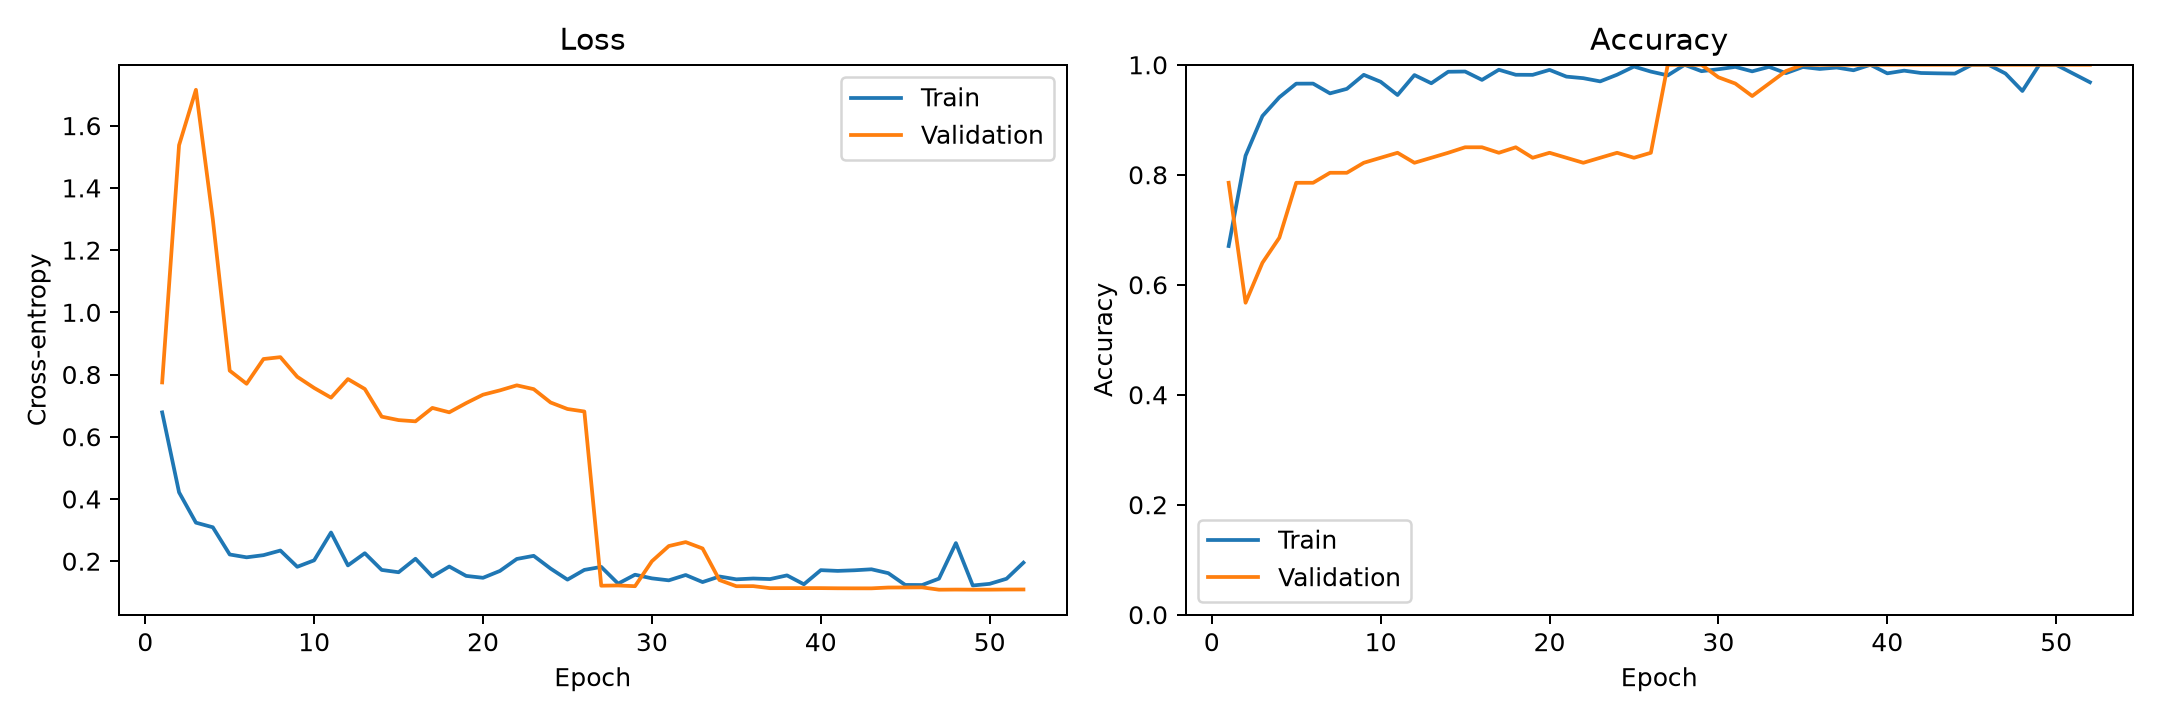

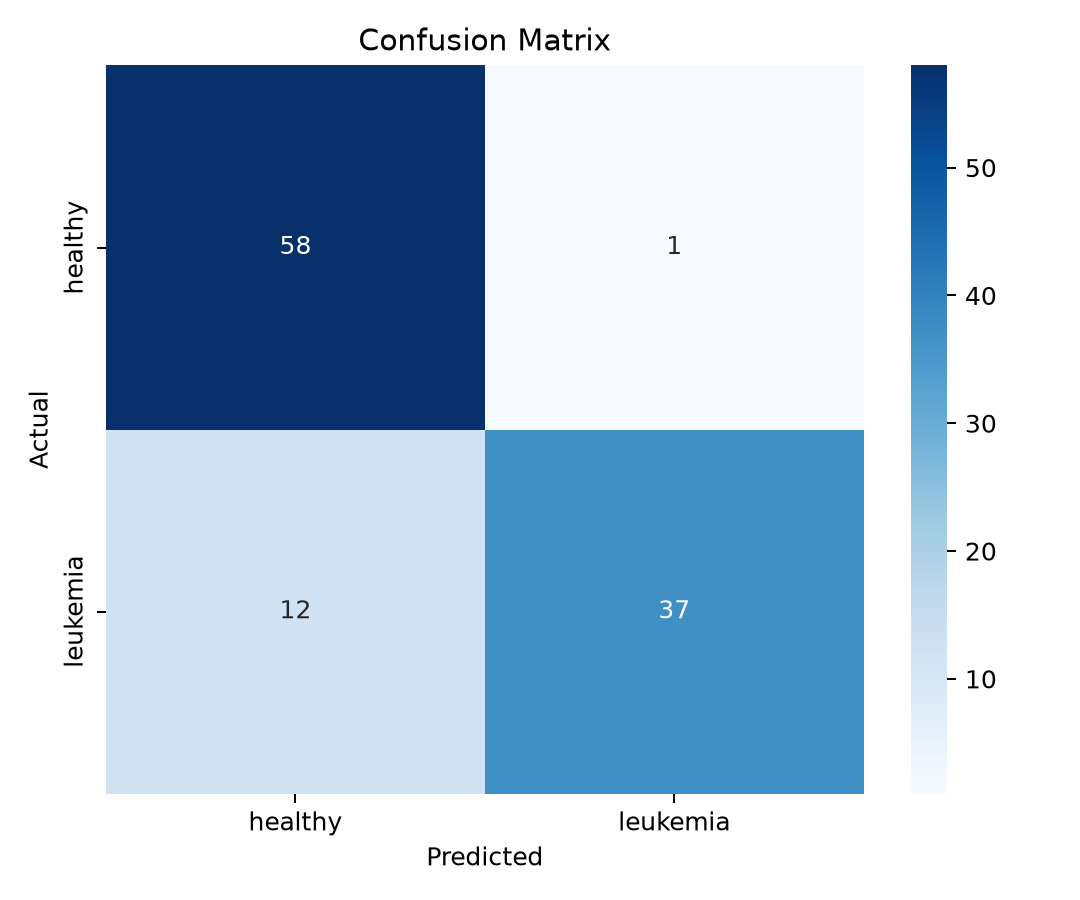

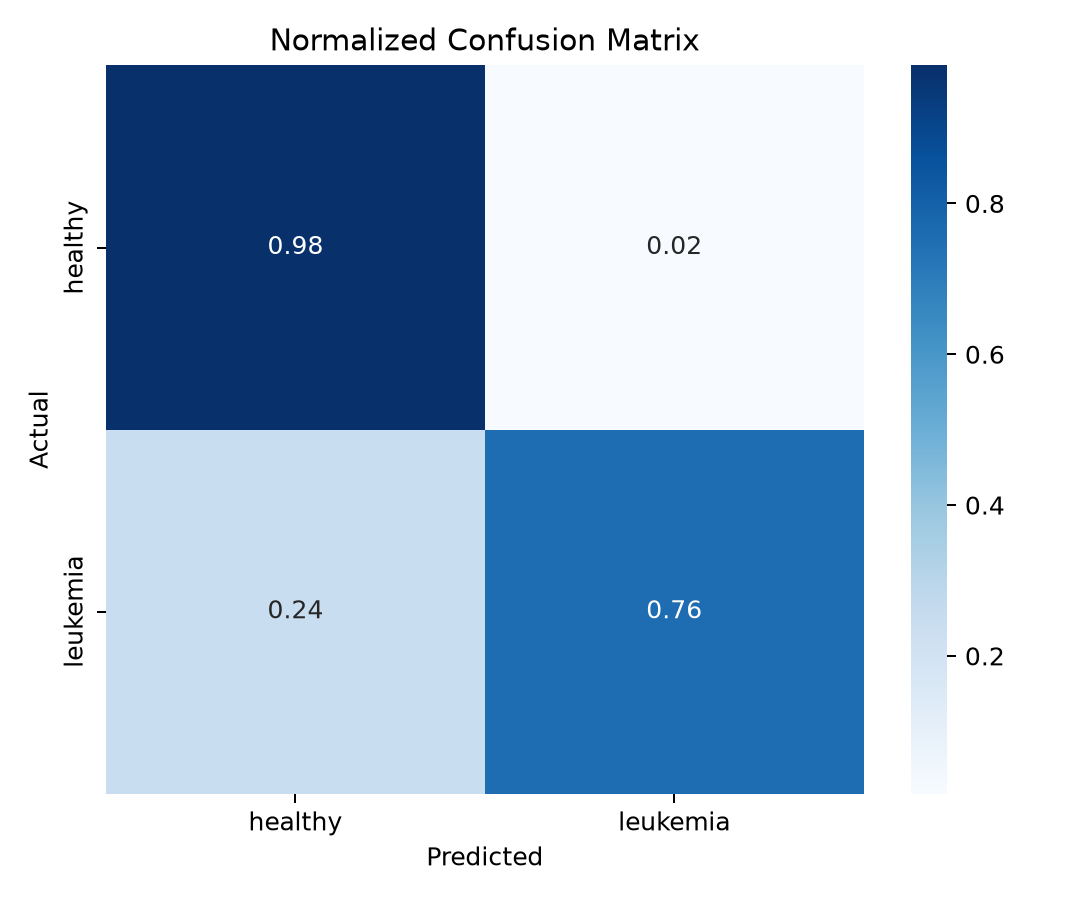

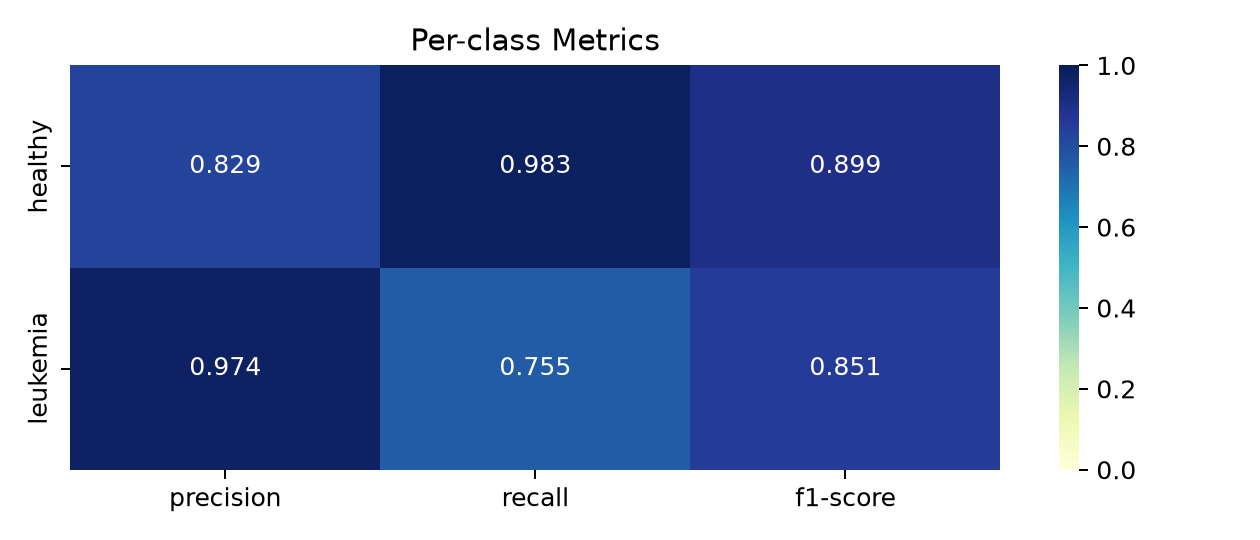

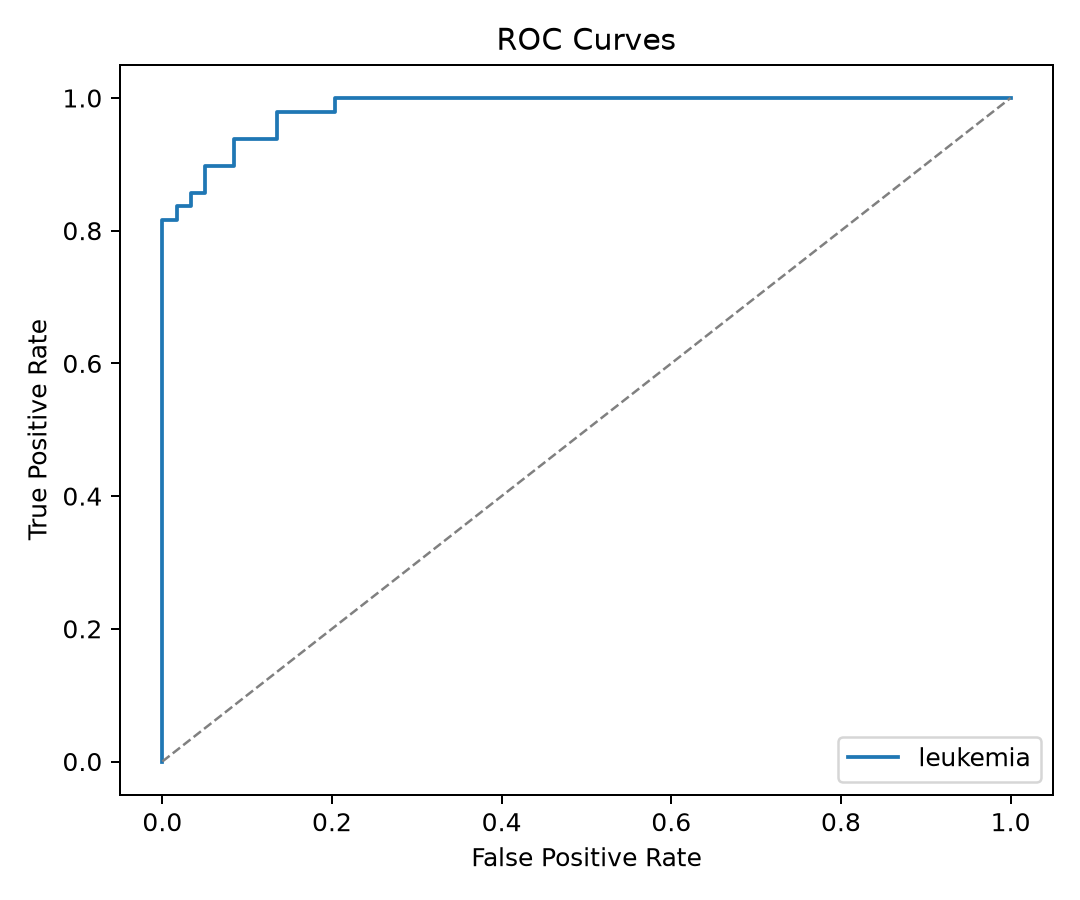

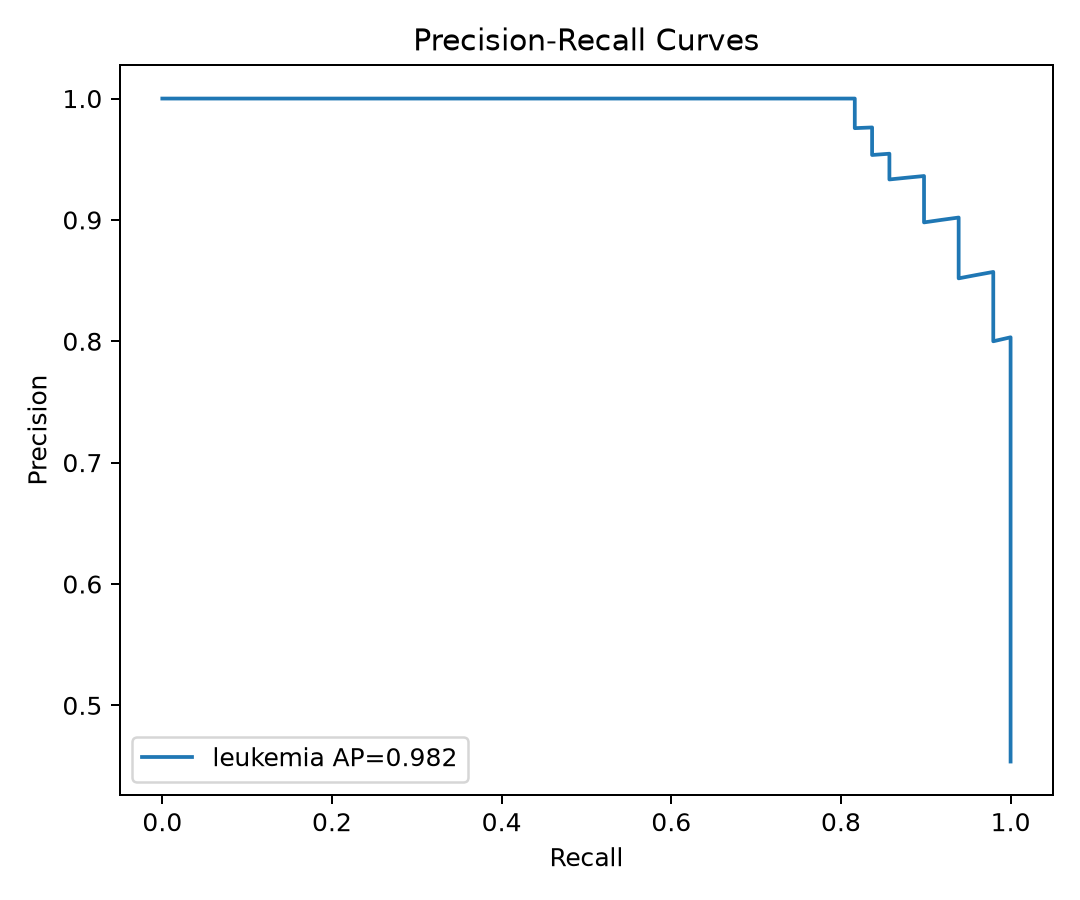

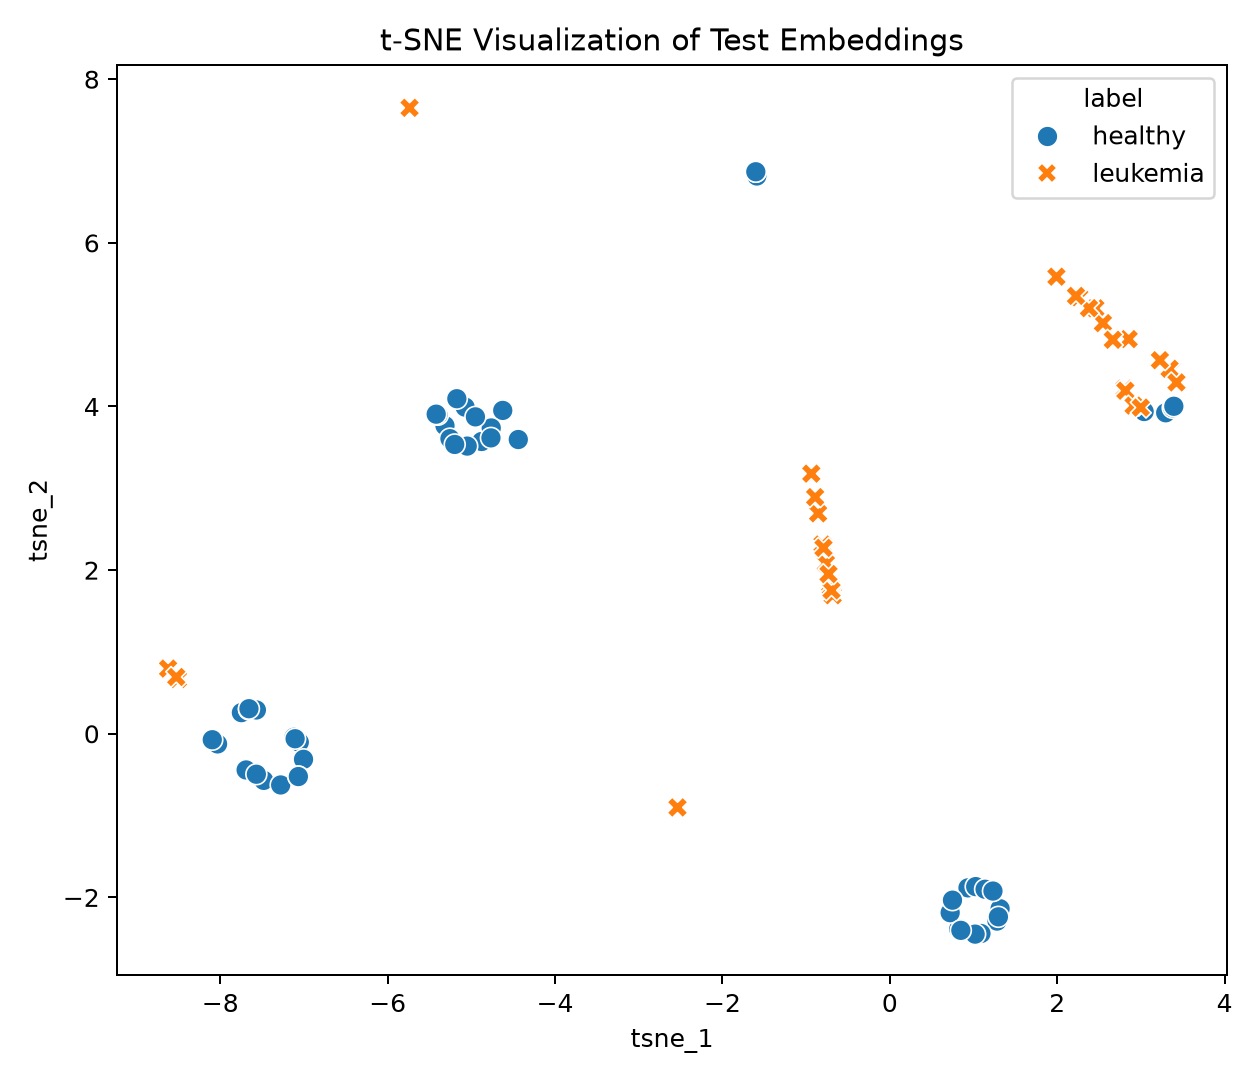

In [8]:
STRICT_RESULT_DIR = PROJECT_ROOT / "results" / "hybrid_cnn_transformer_vgg_grouped"
BEST_STRICT_RESULT_DIR = PROJECT_ROOT / "results" / "hybrid_cnn_transformer_vgg_grouped_calibrated_tta"
SEGMENTED_STRICT_RESULT_DIR = PROJECT_ROOT / "results" / "hybrid_cnn_transformer_vgg_segmented_threshold_fast"
RESULT_DIR = STRICT_RESULT_DIR

def load_metric_row(run, result_dir, protocol, note):
    metrics = json.loads((result_dir / "metrics.json").read_text(encoding="utf-8"))
    return {
        "run": run,
        "protocol": protocol,
        "accuracy": metrics["Final/Accuracy"],
        "balanced_accuracy": metrics["Final/Balanced_Accuracy"],
        "macro_f1": metrics["Final/F1_Macro"],
        "roc_auc_macro": metrics.get("Final/ROC_AUC_Macro", np.nan),
        "note": note,
    }

strict_runs = [
    load_metric_row(
        "VGG grouped argmax",
        STRICT_RESULT_DIR,
        "strict acquisition-grouped",
        "primary robustness run; this is the 84.26% table",
    )
]
if BEST_STRICT_RESULT_DIR.exists():
    strict_runs.append(
        load_metric_row(
            "VGG grouped calibrated + TTA",
            BEST_STRICT_RESULT_DIR,
            "strict acquisition-grouped",
            "best strict VGG result measured so far",
        )
    )
if SEGMENTED_STRICT_RESULT_DIR.exists():
    strict_runs.append(
        load_metric_row(
            "VGG segmented tuning",
            SEGMENTED_STRICT_RESULT_DIR,
            "strict acquisition-grouped",
            "cell-focused tuning; fold 5 did not generalize",
        )
    )

print("Strict acquisition-grouped VGG comparison")
display(pd.DataFrame(strict_runs))

print("\nPrimary strict grouped final metrics (original VGG run)")
display(pd.read_csv(STRICT_RESULT_DIR / "final_metrics.csv").T.rename(columns={0: "value"}))

if BEST_STRICT_RESULT_DIR.exists():
    print("\nBest strict grouped VGG final metrics measured so far")
    display(pd.read_csv(BEST_STRICT_RESULT_DIR / "final_metrics.csv").T.rename(columns={0: "value"}))
    print("\nBest strict grouped VGG fold metrics")
    display(pd.read_csv(BEST_STRICT_RESULT_DIR / "fold_metrics.csv"))

print("\nAcquisition groups used by the strict grouped split")
display(pd.read_csv(STRICT_RESULT_DIR / "acquisition_group_summary.csv", index_col=0))

print("\nPrimary strict grouped fold metrics")
display(pd.read_csv(STRICT_RESULT_DIR / "fold_metrics.csv"))

best_display_dir = BEST_STRICT_RESULT_DIR if BEST_STRICT_RESULT_DIR.exists() else STRICT_RESULT_DIR
print("\nPer-class metrics for displayed best strict VGG run")
display(pd.read_csv(best_display_dir / "classification_metrics.csv", index_col=0))
print("\nOut-of-fold predictions for displayed best strict VGG run")
display(pd.read_csv(best_display_dir / "predictions.csv"))

for plot_name in (
    "training_curves.png",
    "confusion_matrix_raw.png",
    "confusion_matrix_normalized.png",
    "classification_report.png",
    "roc_curves.png",
    "pr_curves.png",
    "tsne_visualization.png",
):
    plot_path = best_display_dir / plot_name
    if plot_path.is_file():
        display(Image(filename=str(plot_path)))


## 8. Secondary paper-comparable image-fold evaluation

The paper reports 99.09% for 10-fold ALL-IDB1 cross-validation, but it uses transfer learning and does not isolate camera/capture sessions. This secondary run uses the paper's image-fold style with the VGG11-BN hybrid backbone while still enforcing exact-duplicate grouping and `weights=None`. It is included for protocol comparison only. The acquisition-grouped result above remains the primary robustness estimate and is never overwritten by this run.

In [9]:
from leukemia_osl.preprocess import content_group_ids

RESULT_DIR = PROJECT_ROOT / "results" / "hybrid_cnn_transformer_vgg_grouped"
paper_content_groups = content_group_ids(records)
assert len(set(paper_content_groups)) == 107
PAPER_COMPARABLE_RESULT_DIR, paper_comparable_fold_metrics = run_hybrid_grouped_cross_validation(
    records,
    paper_content_groups,
    result_name="hybrid_cnn_transformer_vgg_paper_protocol",
    checkpoint_name="hybrid_cnn_transformer_vgg_paper_protocol",
    n_splits=10,
    inner_splits=8,
    group_name="content_group",
    group_source="SHA-256 exact-content groups; image-level folds otherwise",
    bootstrap_unit="content_group",
)
display(
    paper_comparable_fold_metrics[
        [
            "Fold",
            "Final/Accuracy",
            "Final/F1_Macro",
            "Training/Generalization_Gap",
            "Evaluation/Test_Groups",
        ]
    ]
)



train:   0%|                                             | 0/6 [00:00<?, ?it/s]


train:  17%|██████▏                              | 1/6 [00:00<00:04,  1.12it/s]


train:  33%|████████████▎                        | 2/6 [00:01<00:03,  1.13it/s]


train:  50%|██████████████████▌                  | 3/6 [00:02<00:02,  1.19it/s]


train:  67%|████████████████████████▋            | 4/6 [00:03<00:01,  1.15it/s]

...


eval: 100%|██████████████████████████████████████| 1/1 [00:00<00:00,  1.59it/s]


eval:   0%|                                              | 0/1 [00:00<?, ?it/s]


eval: 100%|██████████████████████████████████████| 1/1 [00:00<00:00,  2.00it/s]

Fold 10/10: test_accuracy=1.0000, best_epoch=39, gap=-0.0581, test_groups=10


,Fold,Final/Accuracy,Final/F1_Macro,Training/Generalization_Gap,Evaluation/Test_Groups
0,1,1.000000,1.000000,-0.071429,10
1,2,1.000000,1.000000,-0.071429,11
2,3,1.000000,1.000000,-0.023810,11
3,4,1.000000,1.000000,-0.035714,11
4,5,0.909091,0.909091,-0.011905,11
5,6,1.000000,1.000000,-0.035294,11
6,7,1.000000,1.000000,-0.035714,11
7,8,1.000000,1.000000,-0.047059,10
8,9,1.000000,1.000000,0.000000,11
9,10,1.000000,1.000000,-0.058140,10


## 9. Paper-protocol comparison and saved results

This cell intentionally separates protocols. The strict acquisition-grouped VGG result is the robustness estimate; the paper-comparable result is easier because exact duplicate groups are isolated, but acquisition/camera sessions can still appear across folds.


In [8]:
primary_strict_metrics = json.loads((STRICT_RESULT_DIR / "metrics.json").read_text(encoding="utf-8"))
best_strict_metrics = json.loads((BEST_STRICT_RESULT_DIR / "metrics.json").read_text(encoding="utf-8"))
paper_protocol_metrics = json.loads(
    (PAPER_COMPARABLE_RESULT_DIR / "metrics.json").read_text(encoding="utf-8")
)
protocol_comparison = pd.DataFrame(
    [
        {
            "model / protocol": "VGG hybrid, acquisition-grouped argmax",
            "pretrained": False,
            "accuracy": primary_strict_metrics["Final/Accuracy"],
            "balanced_accuracy": primary_strict_metrics["Final/Balanced_Accuracy"],
            "macro_f1": primary_strict_metrics["Final/F1_Macro"],
            "roc_auc_macro": primary_strict_metrics["Final/ROC_AUC_Macro"],
        },
        {
            "model / protocol": "VGG hybrid, acquisition-grouped calibrated + TTA",
            "pretrained": False,
            "accuracy": best_strict_metrics["Final/Accuracy"],
            "balanced_accuracy": best_strict_metrics["Final/Balanced_Accuracy"],
            "macro_f1": best_strict_metrics["Final/F1_Macro"],
            "roc_auc_macro": best_strict_metrics["Final/ROC_AUC_Macro"],
        },
        {
            "model / protocol": "VGG hybrid, paper-comparable image folds",
            "pretrained": False,
            "accuracy": paper_protocol_metrics["Final/Accuracy"],
            "balanced_accuracy": paper_protocol_metrics["Final/Balanced_Accuracy"],
            "macro_f1": paper_protocol_metrics["Final/F1_Macro"],
            "roc_auc_macro": paper_protocol_metrics["Final/ROC_AUC_Macro"],
        },
        {
            "model / protocol": "Paper ResNet18-OSL reported 10-fold",
            "pretrained": True,
            "accuracy": 0.9909,
            "balanced_accuracy": np.nan,
            "macro_f1": 0.9899,
            "roc_auc_macro": 0.9900,
        },
    ]
)
display(protocol_comparison)
print("Paper-comparable result files:")
for result_path in sorted(PAPER_COMPARABLE_RESULT_DIR.iterdir()):
    if result_path.is_file():
        print("-", result_path.name)
display(pd.read_csv(PAPER_COMPARABLE_RESULT_DIR / "final_metrics.csv").T.rename(columns={0: "value"}))
display(pd.read_csv(PAPER_COMPARABLE_RESULT_DIR / "predictions.csv"))
for plot_name in (
    "training_curves.png",
    "confusion_matrix_raw.png",
    "classification_report.png",
    "roc_curves.png",
    "pr_curves.png",
):
    plot_path = PAPER_COMPARABLE_RESULT_DIR / plot_name
    if plot_path.is_file():
        display(Image(filename=str(plot_path)))


NameError: name 'STRICT_RESULT_DIR' is not defined

## Interpretation boundary

Acquisition grouping is a defensible leakage check, not a substitute for unavailable patient IDs
or an external hospital dataset. A high score can still reflect ALL-IDB1-specific staining and
capture conditions. Generalization claims require patient-level metadata and external validation.
The notebook guarantees random initialization, group isolation, and measured outputs only.